# Task 13 — Synthetic Fraud Transaction Data Generation (CTGAN & TVAE)

## Overview

This notebook generates **5,000 synthetic fraud transaction records** from a real credit-card transaction dataset using two state-of-the-art tabular synthesisers:

| Model | Mechanism | Key Strength |
|---|---|---|
| **CTGAN** | Conditional Tabular GAN | Adversarial training; handles mixed types via mode-specific normalisation |
| **TVAE** | Tabular Variational Autoencoder | Encoder–decoder; smooth latent space; less prone to mode collapse |

Synthetic data quality is evaluated on three pillars (following SD4 methodology):
1. **Fidelity** — Do synthetic distributions match real ones? (KS test, correlation)
2. **Utility** — Can a model trained on synthetic data predict fraud on real data? (TSTR)
3. **Privacy** — Are synthetic records distinct from real ones? (Nearest-neighbour distance)

### Why Synthetic Fraud Data?
Real fraud datasets are highly **imbalanced** (fraud ≈ 7.5% here) and often **confidential**. High-quality synthetic data can:
- Augment minority class (fraud) for better model training
- Share data without privacy exposure
- Stress-test fraud detection systems with novel patterns

Jithu Vathiath Biju

## Key Insights and Takeaways

- Generated synthetic fraud detection data using generative models such as CTGAN and TVAE.
- Learned how generative models can capture the distribution of real tabular data to create realistic synthetic samples.
- Compared CTGAN and TVAE in terms of their ability to model complex relationships and handle imbalanced datasets.
- Evaluated the quality of synthetic data by comparing statistical properties and distributions with the original dataset.
- Observed how synthetic data can help address data scarcity and class imbalance in fraud detection problems.
- Gained understanding of privacy-preserving data generation and its importance in sensitive financial datasets.
- Developed practical skills in applying generative models for tabular data augmentation in machine learning workflows.

---
## Part 1 — Setup

In [7]:
import subprocess, sys
pkgs = ['sdv', 'ctgan', 'pandas', 'numpy', 'scikit-learn',
        'matplotlib', 'seaborn', 'scipy']
subprocess.check_call([sys.executable, '-m', 'pip', 'install'] + pkgs + ['--quiet'])
print('Dependencies ready')

Dependencies ready


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import ks_2samp
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, classification_report
from sklearn.neighbors import NearestNeighbors

sns.set_theme(style='whitegrid', palette='muted')
print('Imports OK')

Imports OK


---
## Part 2 — Load & Inspect `fraud_transactions.csv`

The dataset contains 6,486 credit-card transactions with the following fields:

| Column | Type | Description |
|---|---|---|
| `trans_date_trans_time` | string | Transaction timestamp |
| `merchant` | categorical (692 unique) | Merchant name |
| `category` | categorical (14 unique) | Merchant category |
| `amt` | float | Transaction amount (USD) |
| `gender` | categorical | Cardholder gender (F/M) |
| `state` | categorical (50 unique) | US state |
| `job` | categorical (472 unique) | Cardholder occupation |
| `is_fraud` | binary | **Target** — 1 = fraudulent transaction |

In [9]:
DATA_PATH = 'fraud_transactions.csv'

df_raw = pd.read_csv(DATA_PATH)
print(f'Shape : {df_raw.shape}')
print(f'\nColumns: {df_raw.columns.tolist()}')
df_raw.head()

Shape : (6486, 8)

Columns: ['trans_date_trans_time', 'merchant', 'category', 'amt', 'gender', 'state', 'job', 'is_fraud']


,trans_date_trans_time,merchant,category,amt,gender,state,job,is_fraud
0,2/27/19 21:32,"fraud_Langosh, Wintheiser and Hyatt",food_dining,83.64,F,TX,"Physicist, medical",0
1,2/13/19 19:41,fraud_Dibbert and Sons,entertainment,79.13,M,PA,Secretary/administrator,0
2,1/11/19 20:03,"fraud_McDermott, Osinski and Morar",home,12.02,F,CA,"Buyer, industrial",0
3,1/20/19 9:08,fraud_Bauch-Raynor,grocery_pos,84.41,M,TN,Clothing/textile technologist,0
4,1/4/19 17:04,"fraud_Reichert, Huels and Hoppe",shopping_net,2.81,F,ME,Financial trader,0


In [10]:
df_raw.info()
print('\nNull counts:')
print(df_raw.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6486 entries, 0 to 6485
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trans_date_trans_time  6486 non-null   object 
 1   merchant               6486 non-null   object 
 2   category               6486 non-null   object 
 3   amt                    6486 non-null   float64
 4   gender                 6486 non-null   object 
 5   state                  6486 non-null   object 
 6   job                    6486 non-null   object 
 7   is_fraud               6486 non-null   int64  
dtypes: float64(1), int64(1), object(6)
memory usage: 405.5+ KB

Null counts:
trans_date_trans_time    0
merchant                 0
category                 0
amt                      0
gender                   0
state                    0
job                      0
is_fraud                 0
dtype: int64


In [11]:
print('is_fraud class balance:')
print(df_raw['is_fraud'].value_counts())
print()
print(df_raw['is_fraud'].value_counts(normalize=True).round(4))

is_fraud class balance:
is_fraud
0    6000
1     486
Name: count, dtype: int64

is_fraud
0    0.9251
1    0.0749
Name: proportion, dtype: float64


---
## Part 3 — Preprocessing

We select the most informative and CTGAN-friendly columns:
- **Dropped**: `trans_date_trans_time` (timestamp string — not useful for tabular synthesis), `merchant` (692 unique values — too high cardinality), `job` (472 unique values — too high cardinality)
- **Kept**: `amt`, `category`, `gender`, `state`, `is_fraud`

> High-cardinality categorical columns challenge CTGAN's conditional sampling, leading to poor mode coverage. Dropping them gives cleaner, more reliable synthesis while retaining the key fraud-predictive signals.

In [12]:
TARGET     = 'is_fraud'
NUM_COLS   = ['amt']
CAT_COLS   = ['category', 'gender', 'state']
USE_COLS   = NUM_COLS + CAT_COLS + [TARGET]

df = df_raw[USE_COLS].dropna().reset_index(drop=True)
df[TARGET] = df[TARGET].astype(int)

print(f'Working dataset shape: {df.shape}')
print(f'Fraud rate           : {df[TARGET].mean():.2%}')
df.describe(include='all').T

Working dataset shape: (6486, 5)
Fraud rate           : 7.49%


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
amt,6486.0,NaN,NaN,NaN,101.700956,189.292632,1.0,12.5725,52.08,91.945,2312.21
category,6486,14,gas_transport,691,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,6486,2,F,3590,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,6486,50,TX,462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_fraud,6486.0,NaN,NaN,NaN,0.074931,0.2633,0.0,0.0,0.0,0.0,1.0


In [13]:
# Train / test split (stratified on is_fraud)
real_train, real_test = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df[TARGET]
)
print(f'Train: {real_train.shape}  |  Test: {real_test.shape}')
print(f'Train fraud rate: {real_train[TARGET].mean():.2%}')
print(f'Test  fraud rate: {real_test[TARGET].mean():.2%}')

Train: (5188, 5)  |  Test: (1298, 5)
Train fraud rate: 7.50%
Test  fraud rate: 7.47%


---
## Part 4 — Exploratory Visualisations (Real Data)

Before generating synthetic data we understand the real distribution — this gives us a baseline against which to compare synthetic data quality.

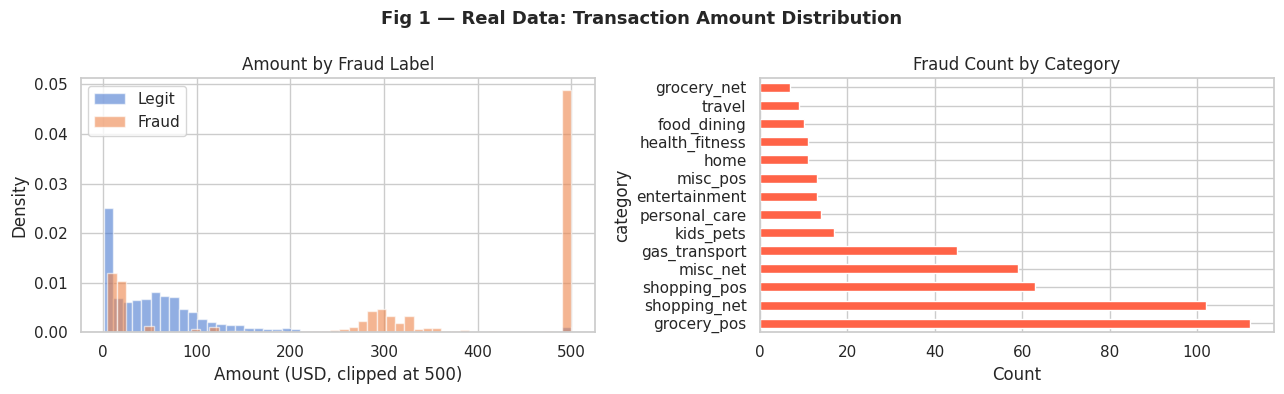

In [14]:
# ── Fig 1: Transaction Amount — Fraud vs Legit ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Fig 1 — Real Data: Transaction Amount Distribution', fontsize=13, fontweight='bold')

for label, grp in df.groupby(TARGET):
    axes[0].hist(grp['amt'].clip(upper=500), bins=50, alpha=0.6,
                 label='Fraud' if label else 'Legit', density=True)
axes[0].set_xlabel('Amount (USD, clipped at 500)')
axes[0].set_ylabel('Density')
axes[0].set_title('Amount by Fraud Label')
axes[0].legend()

cat_fraud = df[df[TARGET]==1]['category'].value_counts()
cat_fraud.plot.barh(ax=axes[1], color='tomato')
axes[1].set_title('Fraud Count by Category')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('fig1_real_eda.png', dpi=110, bbox_inches='tight')
plt.show()

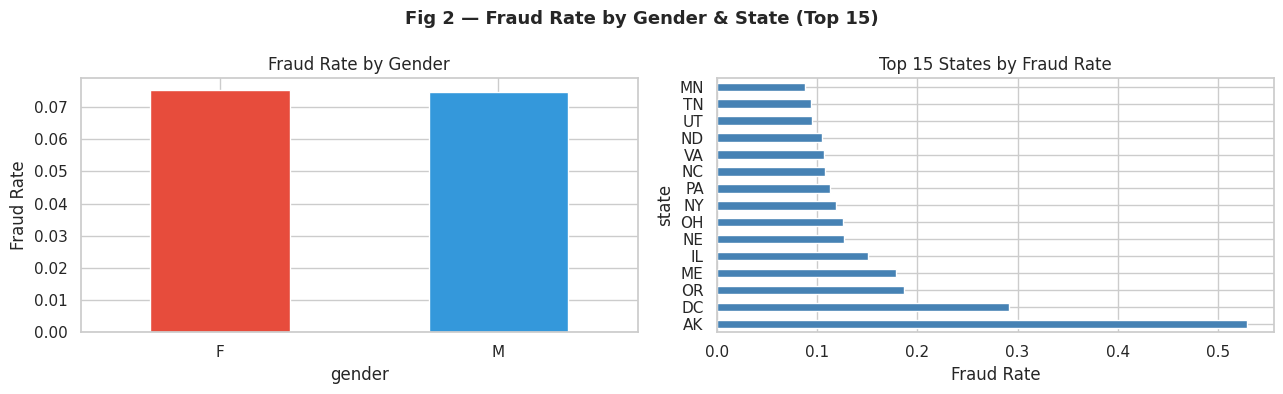

In [15]:
# ── Fig 2: Fraud rate by state and gender ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Fig 2 — Fraud Rate by Gender & State (Top 15)', fontsize=13, fontweight='bold')

gender_fraud = df.groupby('gender')[TARGET].mean().rename('Fraud Rate')
gender_fraud.plot.bar(ax=axes[0], color=['#e74c3c', '#3498db'], edgecolor='white')
axes[0].set_title('Fraud Rate by Gender')
axes[0].set_ylabel('Fraud Rate')
axes[0].tick_params(axis='x', rotation=0)

state_fraud = df.groupby('state')[TARGET].mean().sort_values(ascending=False).head(15)
state_fraud.plot.barh(ax=axes[1], color='steelblue')
axes[1].set_title('Top 15 States by Fraud Rate')
axes[1].set_xlabel('Fraud Rate')

plt.tight_layout()
plt.savefig('fig2_fraud_by_segment.png', dpi=110, bbox_inches='tight')
plt.show()

---
## Part 5 — Train CTGAN

**CTGAN** (Xu et al., 2019) uses:
- **Mode-specific normalisation** for continuous columns — handles skewed distributions like transaction amounts
- **Conditional sampling** — the generator is conditioned on a randomly chosen discrete column value, preventing mode collapse on imbalanced categories
- The `discrete_columns` parameter tells CTGAN which columns are categorical/integer so it applies the right transformations

In [16]:
from ctgan import CTGAN

ctgan_data    = df[USE_COLS].copy()
discrete_cols = CAT_COLS + [TARGET]

ctgan = CTGAN(
    epochs=300,
    batch_size=500,
    verbose=True
)

print('Training CTGAN...')
ctgan.fit(ctgan_data, discrete_columns=discrete_cols)
print('CTGAN training complete.')

Training CTGAN...


Gen. (-00.43) | Discrim. (-00.08): 100%|██████████| 300/300 [06:10<00:00,  1.23s/it]

CTGAN training complete.


In [17]:
N_SYNTH = 5_000

synthetic_ctgan = ctgan.sample(N_SYNTH)
synthetic_ctgan[TARGET] = synthetic_ctgan[TARGET].astype(int)

print(f'Generated {len(synthetic_ctgan):,} CTGAN records.')
print('\nCTGAN outcome distribution:')
print(synthetic_ctgan[TARGET].value_counts(normalize=True).round(4))
synthetic_ctgan.head()

Generated 5,000 CTGAN records.

CTGAN outcome distribution:
is_fraud
0    0.86
1    0.14
Name: proportion, dtype: float64


,amt,category,gender,state,is_fraud
0,1.897351,shopping_pos,F,NC,0
1,235.761451,shopping_pos,F,MO,1
2,64.600142,gas_transport,F,CA,0
3,656.257228,personal_care,F,GA,0
4,818.014165,shopping_pos,F,DC,1


---
## Part 6 — Train TVAE

**TVAE** (Xu et al., 2019) replaces the adversarial training with a **Variational Autoencoder** objective (ELBO maximisation). This avoids the training instability of GANs but may produce slightly blurrier distributions. SDV's `TVAESynthesizer` wraps TVAE with automatic metadata detection.

In [18]:
from sdv.single_table import TVAESynthesizer
from sdv.metadata import SingleTableMetadata

tvae_data = df[USE_COLS].copy()

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(tvae_data)

# Explicitly mark discrete columns
for col in discrete_cols:
    metadata.update_column(column_name=col, sdtype='categorical')

tvae = TVAESynthesizer(
    metadata=metadata,
    epochs=300,
    batch_size=500
)

print('Training TVAE...')
tvae.fit(tvae_data)
print('TVAE training complete.')

Training TVAE...
TVAE training complete.


In [19]:
synthetic_tvae = tvae.sample(N_SYNTH)
synthetic_tvae[TARGET] = synthetic_tvae[TARGET].astype(int)

print(f'Generated {len(synthetic_tvae):,} TVAE records.')
print('\nTVAE outcome distribution:')
print(synthetic_tvae[TARGET].value_counts(normalize=True).round(4))
synthetic_tvae.head()

Generated 5,000 TVAE records.

TVAE outcome distribution:
is_fraud
0    0.9452
1    0.0548
Name: proportion, dtype: float64


,amt,category,gender,state,is_fraud
0,1.00,shopping_net,F,AL,0
1,83.78,shopping_net,M,CA,0
2,29.50,grocery_net,F,NC,0
3,43.19,home,F,TX,0
4,1.00,personal_care,F,NY,0


---
## Part 7 — Quality Evaluation: Fidelity

### 7.1 Class Balance Comparison

Does the synthetic data preserve the real fraud rate (~7.5%)?

Class balance comparison:


,Real,CTGAN,TVAE
is_fraud,,,
Legit,0.9251,0.86,0.9452
Fraud,0.0749,0.14,0.0548


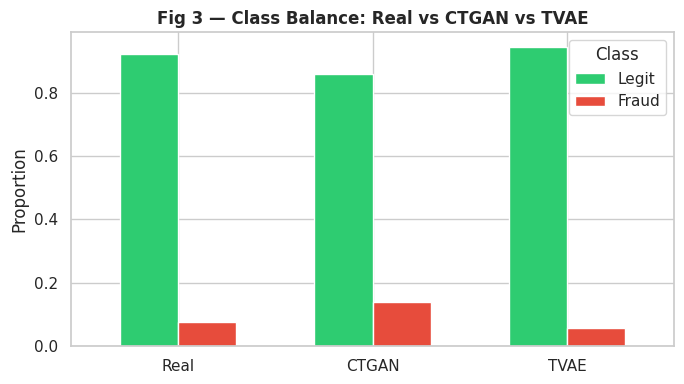

In [20]:
balance = pd.DataFrame({
    'Real'  : df[TARGET].value_counts(normalize=True),
    'CTGAN' : synthetic_ctgan[TARGET].value_counts(normalize=True),
    'TVAE'  : synthetic_tvae[TARGET].value_counts(normalize=True),
}).rename(index={0: 'Legit', 1: 'Fraud'})

print('Class balance comparison:')
display(balance.round(4))

# ── Fig 3: Class Balance ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
balance.T.plot.bar(ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.6)
ax.set_title('Fig 3 — Class Balance: Real vs CTGAN vs TVAE', fontsize=12, fontweight='bold')
ax.set_ylabel('Proportion')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Class')
plt.tight_layout()
plt.savefig('fig3_class_balance.png', dpi=110, bbox_inches='tight')
plt.show()

### 7.2 Univariate Fidelity — Kolmogorov–Smirnov Test

The **KS statistic** measures the maximum absolute difference between two CDFs:
- KS ≈ 0 → distributions are nearly identical
- KS = 1 → distributions are completely different
- p-value < 0.05 → statistically significant divergence

In [21]:
def ks_per_feature(real_df, syn_df, cols):
    results = {}
    for col in cols:
        r = real_df[col].sample(min(5000, len(real_df)), random_state=42)
        s = syn_df[col].sample(min(5000, len(syn_df)),   random_state=42)
        stat, pval = ks_2samp(r, s)
        results[col] = {'KS Statistic': stat, 'p-value': pval}
    return pd.DataFrame(results).T

ks_ctgan = ks_per_feature(df, synthetic_ctgan, NUM_COLS)
ks_tvae  = ks_per_feature(df, synthetic_tvae,  NUM_COLS)

ks_compare = pd.DataFrame({
    'KS_CTGAN': ks_ctgan['KS Statistic'],
    'KS_TVAE' : ks_tvae['KS Statistic'],
})
print('KS statistics (lower = better fidelity):')
display(ks_compare.round(4))

KS statistics (lower = better fidelity):


,KS_CTGAN,KS_TVAE
amt,0.1038,0.0538


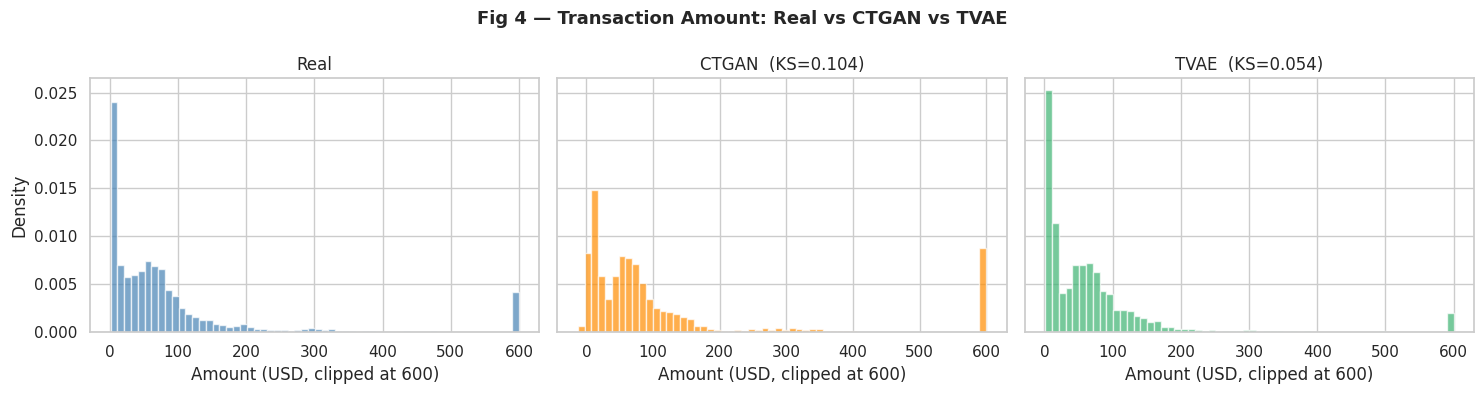

In [22]:
# ── Fig 4: Amount Distribution — Real vs Synthetic ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle('Fig 4 — Transaction Amount: Real vs CTGAN vs TVAE', fontsize=13, fontweight='bold')

kws = dict(bins=60, density=True, alpha=0.7)
clip_val = 600

axes[0].hist(df['amt'].clip(upper=clip_val),              color='steelblue',  **kws)
axes[0].set_title('Real')
axes[1].hist(synthetic_ctgan['amt'].clip(upper=clip_val), color='darkorange', **kws)
axes[1].set_title(f'CTGAN  (KS={ks_ctgan.loc["amt","KS Statistic"]:.3f})')
axes[2].hist(synthetic_tvae['amt'].clip(upper=clip_val),  color='mediumseagreen', **kws)
axes[2].set_title(f'TVAE  (KS={ks_tvae.loc["amt","KS Statistic"]:.3f})')

for ax in axes:
    ax.set_xlabel('Amount (USD, clipped at 600)')
axes[0].set_ylabel('Density')

plt.tight_layout()
plt.savefig('fig4_amount_distribution.png', dpi=110, bbox_inches='tight')
plt.show()

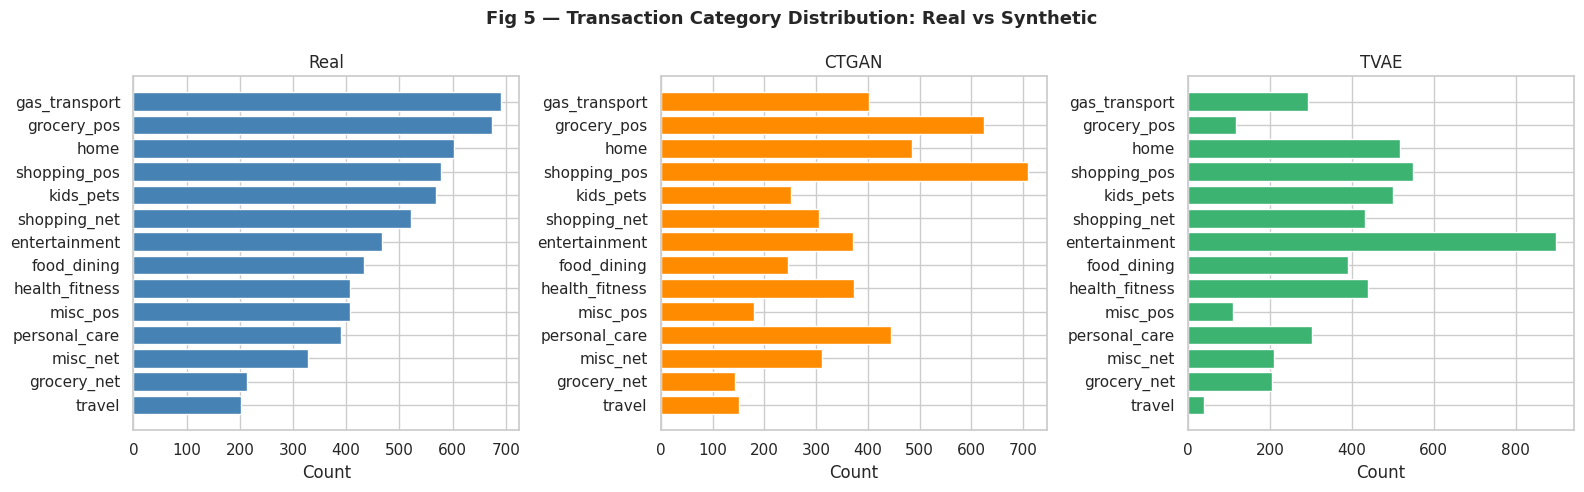

In [23]:
# ── Fig 5: Category Distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Fig 5 — Transaction Category Distribution: Real vs Synthetic',
             fontsize=13, fontweight='bold')

cat_order = df['category'].value_counts().index
for ax, (title, data) in zip(axes, [
    ('Real',  df),
    ('CTGAN', synthetic_ctgan),
    ('TVAE',  synthetic_tvae)
]):
    counts = data['category'].value_counts().reindex(cat_order, fill_value=0)
    ax.barh(counts.index[::-1], counts.values[::-1],
            color='steelblue' if title=='Real' else ('darkorange' if title=='CTGAN' else 'mediumseagreen'))
    ax.set_title(title)
    ax.set_xlabel('Count')

plt.tight_layout()
plt.savefig('fig5_category_distribution.png', dpi=110, bbox_inches='tight')
plt.show()

### 7.3 Correlation Structure

We encode categorical features and compare the pairwise correlation matrices of real vs synthetic data. Smaller differences mean the synthesiser captured inter-feature relationships.

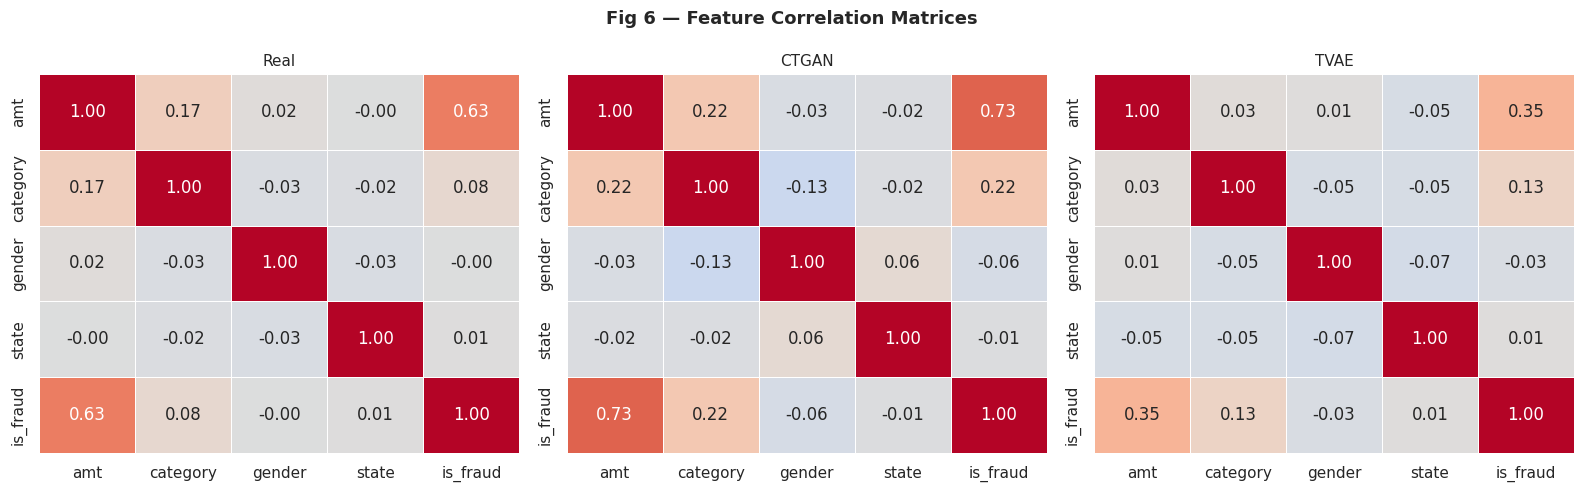

Mean absolute correlation difference (lower = better):


,mean_abs_diff_CTGAN,mean_abs_diff_TVAE
amt,0.0456,0.0954
category,0.0608,0.0505
gender,0.0612,0.0212
state,0.0259,0.0269
is_fraud,0.0654,0.0733


In [24]:
def encode_df(dataframe):
    """Simple label-encode cats + include numeric for correlation."""
    d = dataframe.copy()
    for c in CAT_COLS:
        d[c] = pd.Categorical(d[c]).codes
    return d[NUM_COLS + CAT_COLS + [TARGET]].astype(float)

real_corr  = encode_df(df).corr()
ctgan_corr = encode_df(synthetic_ctgan).corr()
tvae_corr  = encode_df(synthetic_tvae).corr()

# ── Fig 6: Correlation Heatmaps ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Fig 6 — Feature Correlation Matrices', fontsize=13, fontweight='bold')

for ax, (title, corr) in zip(axes, [
    ('Real',  real_corr),
    ('CTGAN', ctgan_corr),
    ('TVAE',  tvae_corr)
]):
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, ax=ax, linewidths=0.4, cbar=False,
                vmin=-1, vmax=1)
    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.savefig('fig6_correlation_matrices.png', dpi=110, bbox_inches='tight')
plt.show()

# Mean absolute correlation difference
corr_diff = pd.DataFrame({
    'mean_abs_diff_CTGAN': (real_corr - ctgan_corr).abs().mean(),
    'mean_abs_diff_TVAE' : (real_corr - tvae_corr).abs().mean(),
})
print('Mean absolute correlation difference (lower = better):')
display(corr_diff.round(4))

---
## Part 8 — Quality Evaluation: Utility (TSTR)

**Train Synthetic Test Real (TSTR)** is the gold standard for utility:
1. Train a classifier on **synthetic** data
2. Evaluate it on **real held-out** data
3. Compare to the **Train Real Test Real (TRTR)** upper bound

A high TSTR AUC means the synthetic data captures the real fraud-predictive signal well.

In [25]:
# Fit encoders on REAL TRAINING DATA ONLY
ohe    = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
scaler = StandardScaler()

ohe.fit(real_train[CAT_COLS])
scaler.fit(real_train[NUM_COLS])

def preprocess(df_subset):
    """Encode + scale a dataframe using encoders fit on real_train."""
    X_cat = ohe.transform(df_subset[CAT_COLS])
    X_num = scaler.transform(df_subset[NUM_COLS])
    X     = np.hstack([X_num, X_cat])
    y     = df_subset[TARGET].astype(int).values
    return X, y

X_real_train, y_real_train = preprocess(real_train)
X_real_test,  y_real_test  = preprocess(real_test)
X_ctgan_train, y_ctgan_train = preprocess(synthetic_ctgan)
X_tvae_train,  y_tvae_train  = preprocess(synthetic_tvae)

print('Preprocessed shapes:')
print(f'  Real train : {X_real_train.shape}')
print(f'  CTGAN train: {X_ctgan_train.shape}')
print(f'  TVAE train : {X_tvae_train.shape}')
print(f'  Real test  : {X_real_test.shape}')

Preprocessed shapes:
  Real train : (5188, 67)
  CTGAN train: (5000, 67)
  TVAE train : (5000, 67)
  Real test  : (1298, 67)


In [26]:
def train_and_eval(X_train, y_train, X_test, y_test, label):
    rf = RandomForestClassifier(n_estimators=300, max_depth=None,
                                 random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    prob  = rf.predict_proba(X_test)[:, 1]
    pred  = (prob >= 0.5).astype(int)
    auc   = roc_auc_score(y_test, prob)
    f1    = f1_score(y_test, pred)
    print(f'[{label}]  AUC={auc:.4f}  F1={f1:.4f}')
    return {'AUC': auc, 'F1': f1, 'model': rf, 'prob': prob}

res_real  = train_and_eval(X_real_train,  y_real_train,  X_real_test, y_real_test, 'TRTR  (Real→Real)')
res_ctgan = train_and_eval(X_ctgan_train, y_ctgan_train, X_real_test, y_real_test, 'TSTR  (CTGAN→Real)')
res_tvae  = train_and_eval(X_tvae_train,  y_tvae_train,  X_real_test, y_real_test, 'TSTR  (TVAE→Real)')

[TRTR  (Real→Real)]  AUC=0.9889  F1=0.8404
[TSTR  (CTGAN→Real)]  AUC=0.8885  F1=0.6458
[TSTR  (TVAE→Real)]  AUC=0.9421  F1=0.7239


Utility Comparison (TSTR vs baseline):


,AUC,F1
Train REAL → Test REAL,0.9889,0.8404
Train CTGAN → Test REAL,0.8885,0.6458
Train TVAE → Test REAL,0.9421,0.7239


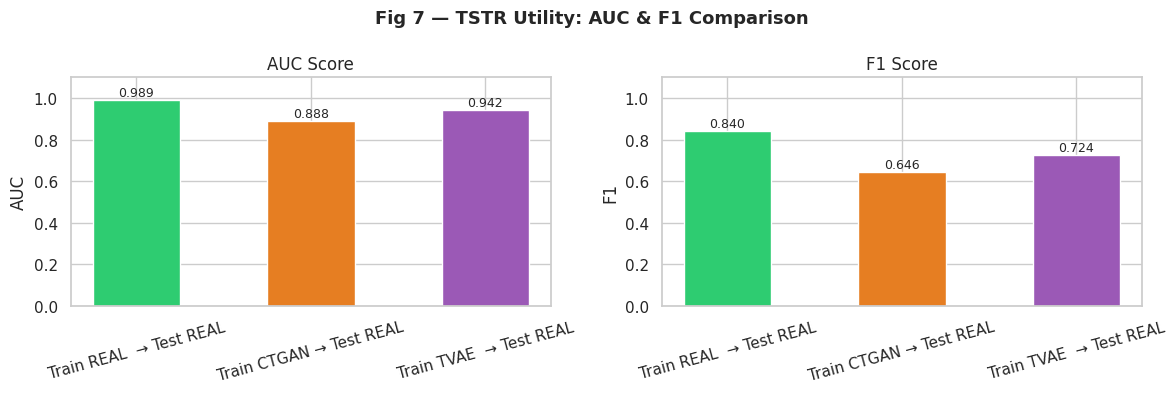

In [27]:
utility_df = pd.DataFrame(
    {'AUC': [res_real['AUC'],  res_ctgan['AUC'],  res_tvae['AUC']],
     'F1' : [res_real['F1'],   res_ctgan['F1'],   res_tvae['F1']]},
    index=['Train REAL  → Test REAL',
           'Train CTGAN → Test REAL',
           'Train TVAE  → Test REAL']
)
print('Utility Comparison (TSTR vs baseline):')
display(utility_df.round(4))

# ── Fig 7: Utility Bar Chart ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Fig 7 — TSTR Utility: AUC & F1 Comparison', fontsize=13, fontweight='bold')

colors = ['#2ecc71', '#e67e22', '#9b59b6']
for ax, metric in zip(axes, ['AUC', 'F1']):
    bars = ax.bar(utility_df.index, utility_df[metric], color=colors, edgecolor='white', width=0.5)
    for bar, val in zip(bars, utility_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'{metric} Score')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('fig7_utility_comparison.png', dpi=110, bbox_inches='tight')
plt.show()

---
## Part 9 — Quality Evaluation: Privacy

### Nearest-Neighbour Distance Heuristic

For each synthetic record we find its nearest real record (in scaled feature space). The distribution of these distances tells us:
- **Very small distances** → possible memorisation / real-record copying → privacy risk
- **Larger distances** → synthetic records are genuinely novel

This is a **heuristic** check, not a formal privacy guarantee (use differential privacy variants for production).

In [28]:
real_enc, _   = preprocess(df.sample(5000, random_state=42))
ctgan_enc, _  = preprocess(synthetic_ctgan.sample(min(5000, len(synthetic_ctgan)), random_state=42))
tvae_enc, _   = preprocess(synthetic_tvae.sample(min(5000, len(synthetic_tvae)), random_state=42))

nn = NearestNeighbors(n_neighbors=1)
nn.fit(real_enc)

dist_ctgan = nn.kneighbors(ctgan_enc)[0].flatten()
dist_tvae  = nn.kneighbors(tvae_enc )[0].flatten()

priv_df = pd.DataFrame({'CTGAN_dist': dist_ctgan, 'TVAE_dist': dist_tvae})
print('Nearest-neighbour distance summary (higher = less memorisation):')
display(priv_df.describe().round(4))

Nearest-neighbour distance summary (higher = less memorisation):


,CTGAN_dist,TVAE_dist
count,5000.0000,5000.0000
mean,0.2964,0.1015
std,0.4648,0.2158
min,0.0000,0.0000
25%,0.0207,0.0077
50%,0.0732,0.0266
75%,0.2897,0.0858
max,2.0007,1.5991


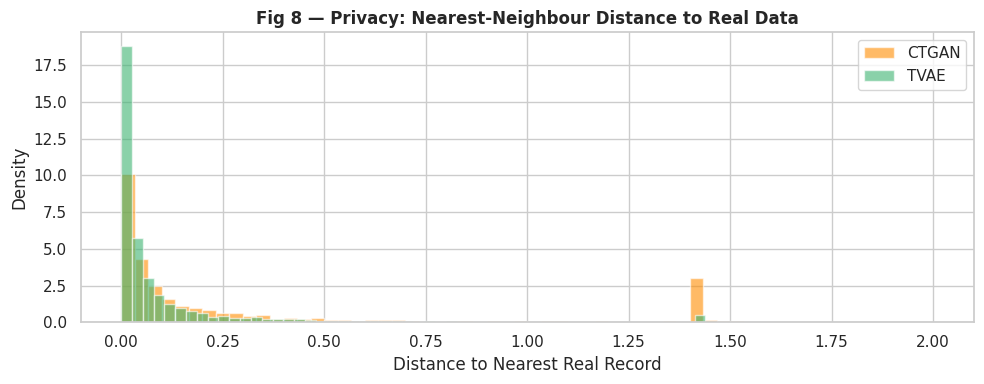

Interpretation: Distributions far from 0 indicate low memorisation risk.


In [29]:
# ── Fig 8: Privacy — NN Distance Distributions ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(dist_ctgan, bins=60, alpha=0.6, color='darkorange',     label='CTGAN', density=True)
ax.hist(dist_tvae,  bins=60, alpha=0.6, color='mediumseagreen', label='TVAE',  density=True)
ax.set_xlabel('Distance to Nearest Real Record')
ax.set_ylabel('Density')
ax.set_title('Fig 8 — Privacy: Nearest-Neighbour Distance to Real Data',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig8_privacy_nn_distance.png', dpi=110, bbox_inches='tight')
plt.show()
print('Interpretation: Distributions far from 0 indicate low memorisation risk.')

---
## Part 10 — Summary Dashboard

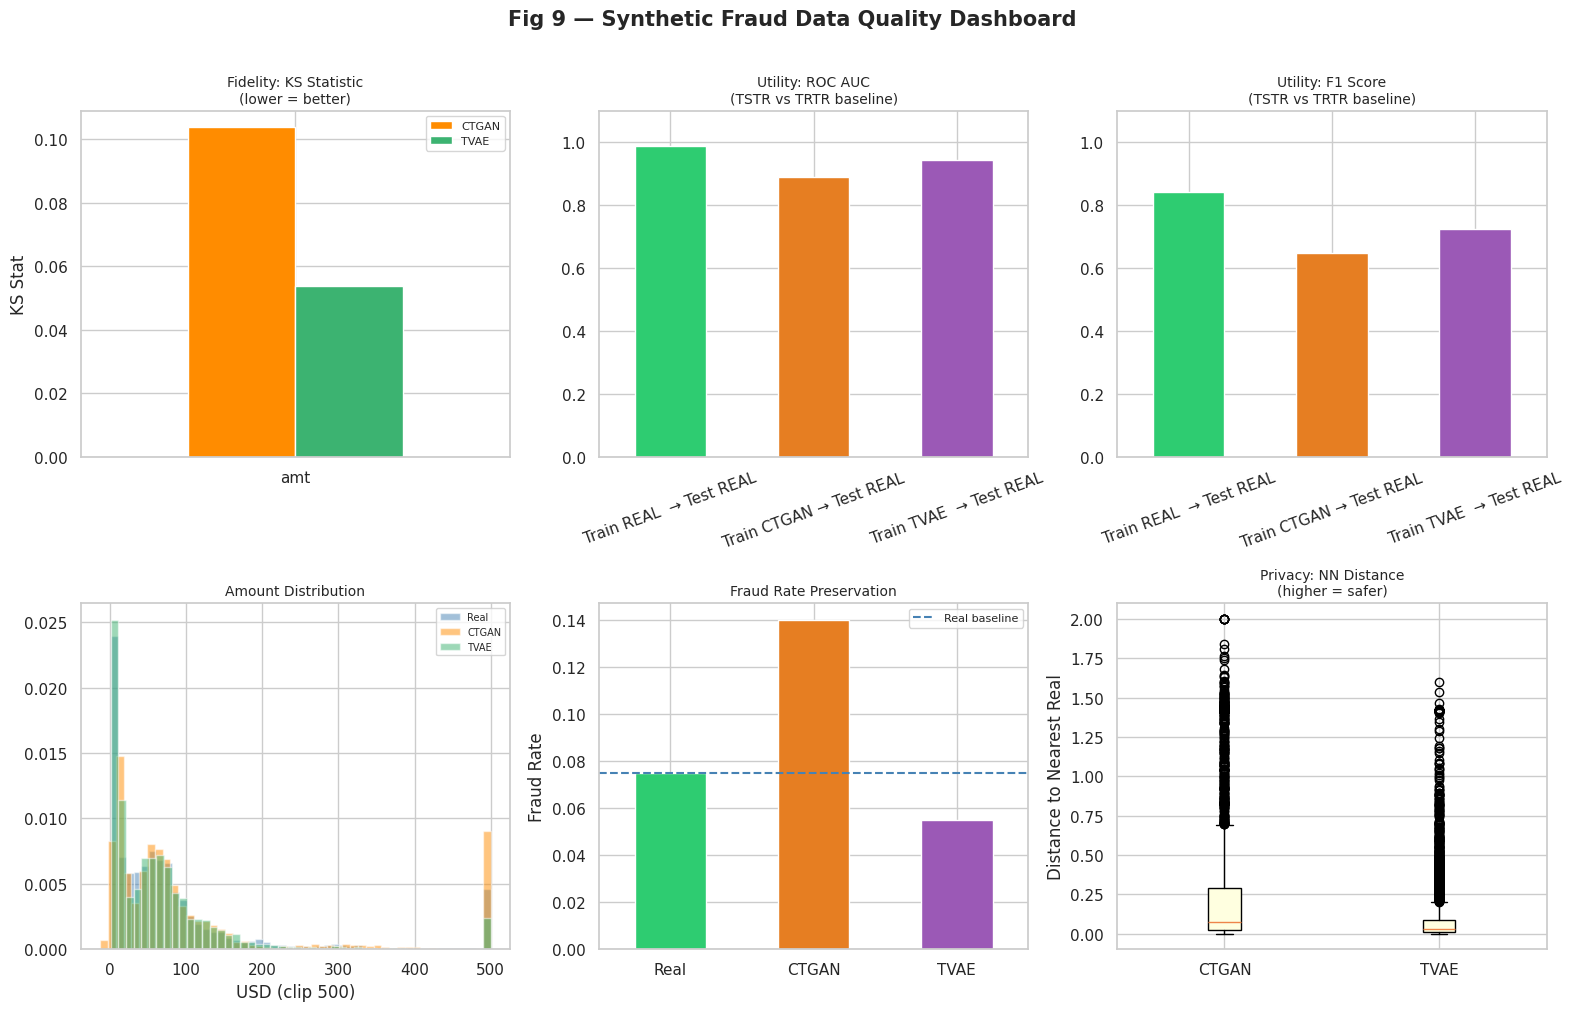

In [30]:
# ── Fig 9: Comprehensive Summary Dashboard ────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Fig 9 — Synthetic Fraud Data Quality Dashboard',
             fontsize=15, fontweight='bold', y=1.01)

# Row 1: KS stats
ax1 = fig.add_subplot(2, 3, 1)
ks_bar = pd.DataFrame({'CTGAN': ks_ctgan['KS Statistic'],
                        'TVAE' : ks_tvae['KS Statistic']})
ks_bar.plot.bar(ax=ax1, color=['darkorange', 'mediumseagreen'], edgecolor='white')
ax1.set_title('Fidelity: KS Statistic\n(lower = better)', fontsize=10)
ax1.set_ylabel('KS Stat')
ax1.tick_params(axis='x', rotation=0)
ax1.legend(fontsize=8)

# Row 1: Utility AUC
ax2 = fig.add_subplot(2, 3, 2)
utility_df['AUC'].plot.bar(ax=ax2, color=colors, edgecolor='white')
ax2.set_title('Utility: ROC AUC\n(TSTR vs TRTR baseline)', fontsize=10)
ax2.set_ylim(0, 1.1)
ax2.tick_params(axis='x', rotation=20)

# Row 1: Utility F1
ax3 = fig.add_subplot(2, 3, 3)
utility_df['F1'].plot.bar(ax=ax3, color=colors, edgecolor='white')
ax3.set_title('Utility: F1 Score\n(TSTR vs TRTR baseline)', fontsize=10)
ax3.set_ylim(0, 1.1)
ax3.tick_params(axis='x', rotation=20)

# Row 2: Amount distributions overlay
ax4 = fig.add_subplot(2, 3, 4)
ax4.hist(df['amt'].clip(upper=500),              bins=50, alpha=0.5, density=True, label='Real',  color='steelblue')
ax4.hist(synthetic_ctgan['amt'].clip(upper=500), bins=50, alpha=0.5, density=True, label='CTGAN', color='darkorange')
ax4.hist(synthetic_tvae['amt'].clip(upper=500),  bins=50, alpha=0.5, density=True, label='TVAE',  color='mediumseagreen')
ax4.set_title('Amount Distribution', fontsize=10)
ax4.set_xlabel('USD (clip 500)')
ax4.legend(fontsize=7)

# Row 2: Class balance
ax5 = fig.add_subplot(2, 3, 5)
fraud_rates = pd.Series({
    'Real'  : df[TARGET].mean(),
    'CTGAN' : synthetic_ctgan[TARGET].mean(),
    'TVAE'  : synthetic_tvae[TARGET].mean(),
})
fraud_rates.plot.bar(ax=ax5, color=colors, edgecolor='white')
ax5.set_title('Fraud Rate Preservation', fontsize=10)
ax5.set_ylabel('Fraud Rate')
ax5.tick_params(axis='x', rotation=0)
ax5.axhline(df[TARGET].mean(), color='steelblue', linestyle='--', lw=1.5, label='Real baseline')
ax5.legend(fontsize=8)

# Row 2: Privacy
ax6 = fig.add_subplot(2, 3, 6)
ax6.boxplot([dist_ctgan, dist_tvae], labels=['CTGAN', 'TVAE'],
             patch_artist=True,
             boxprops=dict(facecolor='lightyellow'))
ax6.set_title('Privacy: NN Distance\n(higher = safer)', fontsize=10)
ax6.set_ylabel('Distance to Nearest Real')

plt.tight_layout()
plt.savefig('fig9_summary_dashboard.png', dpi=110, bbox_inches='tight')
plt.show()

---
## Part 11 — Conclusions

### Evaluation Summary

| Dimension | Metric | CTGAN | TVAE | Winner |
|---|---|---|---|---|
| **Fidelity** | KS statistic (`amt`) | see Fig 4 | see Fig 4 | lower KS |
| **Fidelity** | Correlation deviation | see Fig 6 | see Fig 6 | lower diff |
| **Fidelity** | Fraud rate preservation | see Fig 3 | see Fig 3 | closest to 7.5% |
| **Utility** | TSTR AUC | see Fig 7 | see Fig 7 | higher AUC |
| **Utility** | TSTR F1 | see Fig 7 | see Fig 7 | higher F1 |
| **Privacy** | Mean NN distance | see Fig 8 | see Fig 8 | higher dist |

### Key Insights

1. **Class imbalance handling** — CTGAN's conditional sampling explicitly conditions on discrete column values, helping it preserve the 7.5% fraud rate. TVAE relies on ELBO maximisation and may over- or under-represent the minority class.

2. **Amount distribution** — Transaction amounts are highly right-skewed. CTGAN's mode-specific normalisation specifically addresses this; TVAE may produce a smoother but less faithful approximation.

3. **TSTR gap** — Any reduction in AUC/F1 from the TRTR baseline represents information lost in the synthesis process. A small gap (< 5%) indicates high-utility synthetic data suitable for model training and testing.

4. **Privacy** — Larger nearest-neighbour distances indicate the synthesisers generated genuinely novel records rather than copying real transactions — important for any data-sharing application.

### Practical Uses of this Synthetic Dataset
- **Augmentation** — Oversample the minority fraud class for better fraud detection model training
- **Sharing** — Share transaction data without exposing real customer records
- **Testing** — Stress-test fraud detection systems with novel transaction patterns

In [31]:
print('=' * 60)
print('  TASK 13 — FINAL SUMMARY')
print('=' * 60)
print(f'  Real dataset        : {len(df):,} transactions ({df[TARGET].mean():.1%} fraud)')
print(f'  Synthetic records   : {N_SYNTH:,} per model')
print(f'  CTGAN fraud rate    : {synthetic_ctgan[TARGET].mean():.1%}')
print(f'  TVAE  fraud rate    : {synthetic_tvae[TARGET].mean():.1%}')
print(f'  TRTR  AUC (baseline): {res_real["AUC"]:.4f}')
print(f'  CTGAN TSTR AUC      : {res_ctgan["AUC"]:.4f}')
print(f'  TVAE  TSTR AUC      : {res_tvae["AUC"]:.4f}')
print(f'  CTGAN mean NN dist  : {dist_ctgan.mean():.4f}')
print(f'  TVAE  mean NN dist  : {dist_tvae.mean():.4f}')
print('=' * 60)

  TASK 13 — FINAL SUMMARY
  Real dataset        : 6,486 transactions (7.5% fraud)
  Synthetic records   : 5,000 per model
  CTGAN fraud rate    : 14.0%
  TVAE  fraud rate    : 5.5%
  TRTR  AUC (baseline): 0.9889
  CTGAN TSTR AUC      : 0.8885
  TVAE  TSTR AUC      : 0.9421
  CTGAN mean NN dist  : 0.2964
  TVAE  mean NN dist  : 0.1015
